---
format: 
    html:
        embed-resources: true
---


## EDA: Ride Accuracy Binary dataset

In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [71]:
#load ride accuracy csv file dataset for eda
ride_accuracy = pd.read_csv("../../data/processed-data/Clean_Ride_Accuracy_Binary.csv")

#convert csv file into a dataframe
ride_accuracy_df = pd.DataFrame(ride_accuracy)

print(ride_accuracy_df.head())

   Unnamed: 0      weekly    mode route_id        bin arrival_departure  \
0         780  2020-08-03  subway     Blue    0-3 min           blended   
1         781  2020-08-03  subway     Blue    3-6 min           blended   
2         782  2020-08-03  subway     Blue   6-12 min           blended   
3         783  2020-08-03  subway     Blue  12-30 min           blended   
4         784  2020-08-03  subway  Green-B    0-3 min           blended   

   num_predictions  num_accurate_predictions  Low Range Bin Time (min)  \
0            63612                     58116                         0   
1            65346                     58809                         3   
2           124158                    112668                         6   
3           350575                    314248                        12   
4           144067                    117550                         0   

   High Range Bin Time (min)  Pre and Post 2021  Pre and Post 2021 Binary  
0                          3

In [72]:
#drop unneeded columns
ride_accuracy_drop_df = ride_accuracy_df.drop(["Unnamed: 0"],axis=1)

## Univariate Analysis:

In [73]:
#find outliers and other statistical information using describe()
print(ride_accuracy_drop_df.describe())


       num_predictions  num_accurate_predictions  Low Range Bin Time (min)  \
count     7.184000e+03               7184.000000               7184.000000   
mean      1.900083e+05             154576.004176                  5.250000   
std       1.842277e+05             144457.231305                  4.437369   
min       0.000000e+00                  0.000000                  0.000000   
25%       7.617800e+04              67576.000000                  2.250000   
50%       1.199255e+05             101258.000000                  4.500000   
75%       2.237600e+05             187399.250000                  7.500000   
max       1.158573e+06             904424.000000                 12.000000   

       High Range Bin Time (min)  Pre and Post 2021  Pre and Post 2021 Binary  
count                7184.000000       7.184000e+03               7184.000000  
mean                   12.750000       1.662738e+09                  0.670379  
std                    10.473909       3.750476e+07      

The summary statistics above are of the numerical vairables from the ride accuracy dataset. Statistics show that the features mean and standard deviation are relatively close and do not have severe outliers.

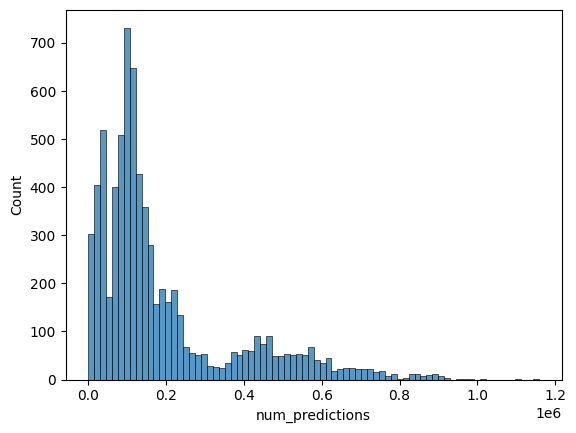

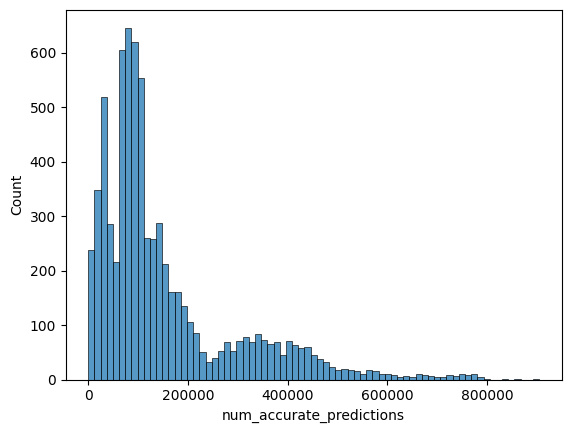

In [116]:
#create histogram plot for num_predictions column
sns.histplot(data = ride_accuracy_drop_df, x = "num_predictions")
plt.show()

#create histogram plot for num_accurate_predictions column
sns.histplot(data = ride_accuracy_drop_df, x = "num_accurate_predictions")
plt.show()

Histograms above show the distribution of the "num_predictions" and "num_accurate predictions". Both histograms have a right skew meaning there were fewer number of predictions and accurate preditictions of subway rides. Not too many outliers.

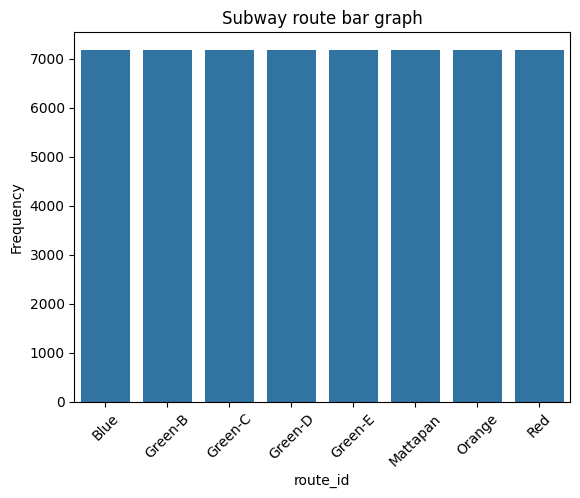

In [74]:
#bar charts to observe categorical variables: different subway routes
route_count = ride_accuracy_drop_df["route_id"].count()

sns.barplot(data = ride_accuracy_drop_df, x = "route_id", y = route_count)
plt.title("Subway route bar graph")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()

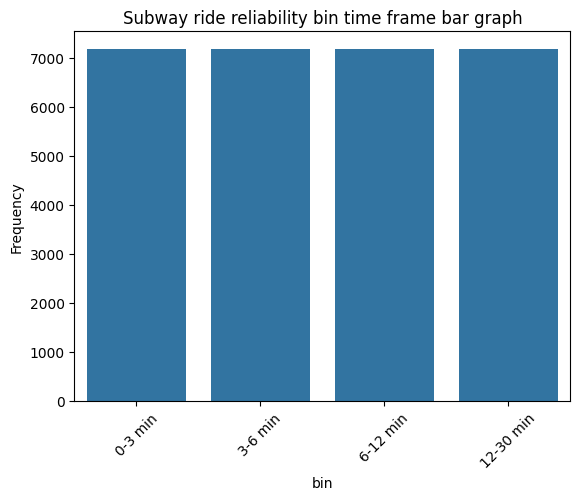

In [75]:
#bar charts to observe categorical variables: bin column
bin_count = ride_accuracy_drop_df["bin"].count()

sns.barplot(data = ride_accuracy_drop_df, x = "bin", y = bin_count)
plt.title("Subway ride reliability bin time frame bar graph")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()

Bar plots above shows the frequency of the categorical variables: route_id and bin. Bar plots show that the number of observations are uniform for all the unique categorical features.

## Bivariate and Multivariate Analysis:

                           num_predictions  num_accurate_predictions  \
num_predictions                   1.000000                  0.982956   
num_accurate_predictions          0.982956                  1.000000   
Low Range Bin Time (min)          0.701063                  0.678770   
High Range Bin Time (min)         0.734128                  0.707786   
Pre and Post 2021 Binary         -0.051032                 -0.067263   

                           Low Range Bin Time (min)  \
num_predictions                        7.010633e-01   
num_accurate_predictions               6.787704e-01   
Low Range Bin Time (min)               1.000000e+00   
High Range Bin Time (min)              9.804686e-01   
Pre and Post 2021 Binary               1.068438e-15   

                           High Range Bin Time (min)  Pre and Post 2021 Binary  
num_predictions                         7.341277e-01             -5.103219e-02  
num_accurate_predictions                7.077863e-01             -6.726284

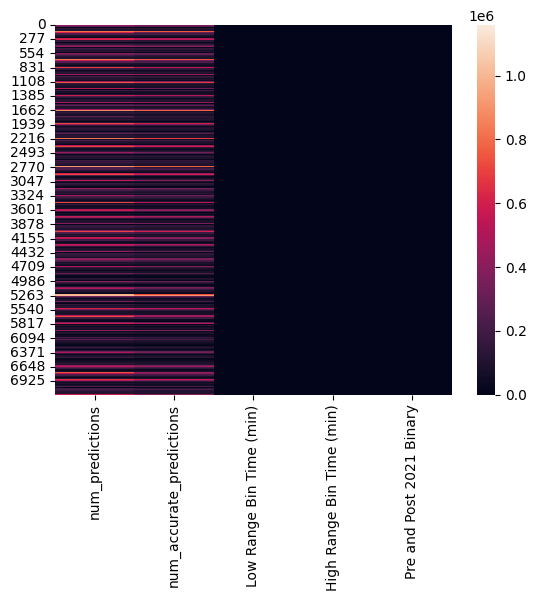

In [76]:
#create correlation matrix of the ride reliability dataframe
#first subset dataframe to only include numerical columns
rel_subset = ride_accuracy_drop_df[["num_predictions",  "num_accurate_predictions", "Low Range Bin Time (min)", "High Range Bin Time (min)", "Pre and Post 2021 Binary"]]
#create correlation matrix
rel_corr_matrix = rel_subset.corr()
print(rel_corr_matrix)


#create heatmap of dataframe subset
sns.heatmap(rel_subset)
plt.show() #show heatmap

The correlation matrix show majority of features in the ride accuracy dataset have high correlation. But majority of those correalations are due to multicollinearity. The heatmap helps to visualize the relations shown in the correlation matrix. The heatmap shows that "num_prediction" and "num_accurate_predictions" features have higher correlation values, and the rest of the features "Low Range Bin Time (min)" and "High Range Bin Time (min)" and "Pre and Post 2021 Binary" have lower correlation values. Thus, it would be best to fit either "num_prediction" or "num_accurate_predictions" in a model to avoid multicollinearity.

In [77]:
#create crosstab of categorical variables
#crosstab variables mode of transportation and the subway route id
pd.crosstab(ride_accuracy_drop_df["mode"], ride_accuracy_drop_df["route_id"])

route_id,Blue,Green-B,Green-C,Green-D,Green-E,Mattapan,Orange,Red
mode,,,,,,,,
subway,900,900,900,900,900,900,884,900


In [78]:
#create crosstab of data between before and after 2022-01-01 and the subway route ids
pd.crosstab(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["route_id"])

route_id,Blue,Green-B,Green-C,Green-D,Green-E,Mattapan,Orange,Red
Pre and Post 2021 Binary,,,,,,,,
0,296,296,296,296,296,296,296,296
1,604,604,604,604,604,604,588,604


In [79]:
#create crosstab of data between before and after 2022-01-01 and the bin of ride arrival time frame
pd.crosstab(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["bin"])

bin,0-3 min,12-30 min,3-6 min,6-12 min
Pre and Post 2021 Binary,,,,
0,592,592,592,592
1,1204,1204,1204,1204


In [80]:
#create crosstab of data between before and after 2022-01-01 and the type of trips made
pd.crosstab(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["arrival_departure"])

arrival_departure,blended
Pre and Post 2021 Binary,
0,2368
1,4816


The crosstabs above shows the relationship of the categorical variables in the ride accuracy dataset. The first crosstab shows the data only includes data on the subway mode of transportation and includes the subway route ids.
The second crosstab shows there were more observations of the subway route-ids post-2021.
The third crosstabl shows 

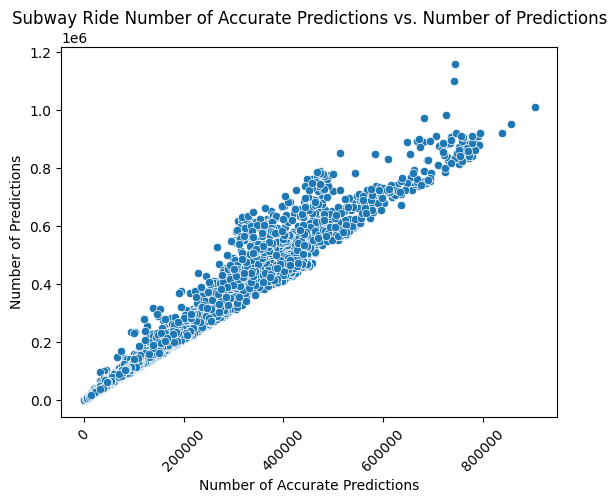

In [81]:
#Feature pairings
#create scatter plots between num_accurate_predictions and num_predictions
sns.scatterplot(data = ride_accuracy_drop_df, x= "num_accurate_predictions", y = "num_predictions")
plt.title("Subway Ride Number of Accurate Predictions vs. Number of Predictions")
plt.xticks(rotation=45)
plt.xlabel("Number of Accurate Predictions")
plt.ylabel("Number of Predictions")
plt.show()


## Data Distribution and Normalization: 

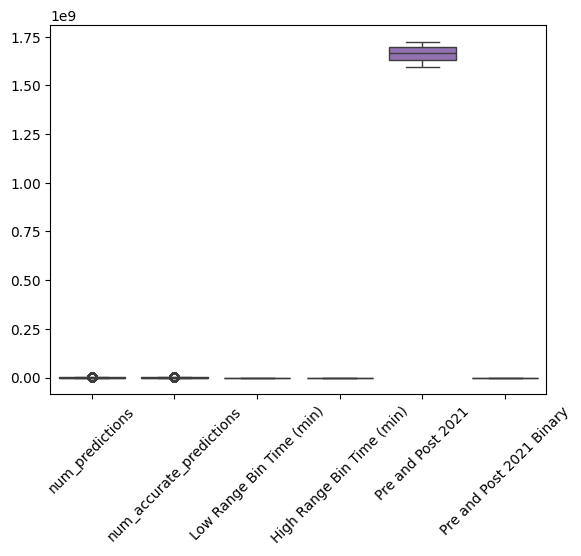

In [82]:
#create boxplot of dataframe to visualize dataset distribution
sns.boxplot(data=ride_accuracy_drop_df)
plt.xticks(rotation=45)
plt.show()

In [83]:
#apply z-score normalization on subset of dataframe that only includes numerical values
#convert subset dataframe into an array
#Only select num_predictions and num_accurate_predictions
accuracy_subset = ride_accuracy_drop_df[["num_predictions", "num_accurate_predictions"]]
ride_accuracy_array = np.array(accuracy_subset)

#compute z-score normalization transformation on array of dataframe subset (x-mean)/standard deviation
normalized_ride_accuracy = (ride_accuracy_array - np.mean(ride_accuracy_array) / np.std(ride_accuracy_array))
print(normalized_ride_accuracy)

[[ 63610.96505666  58114.96505666]
 [ 65344.96505666  58807.96505666]
 [124156.96505666 112666.96505666]
 ...
 [103571.96505666  82494.96505666]
 [203963.96505666 163503.96505666]
 [582949.96505666 397087.96505666]]


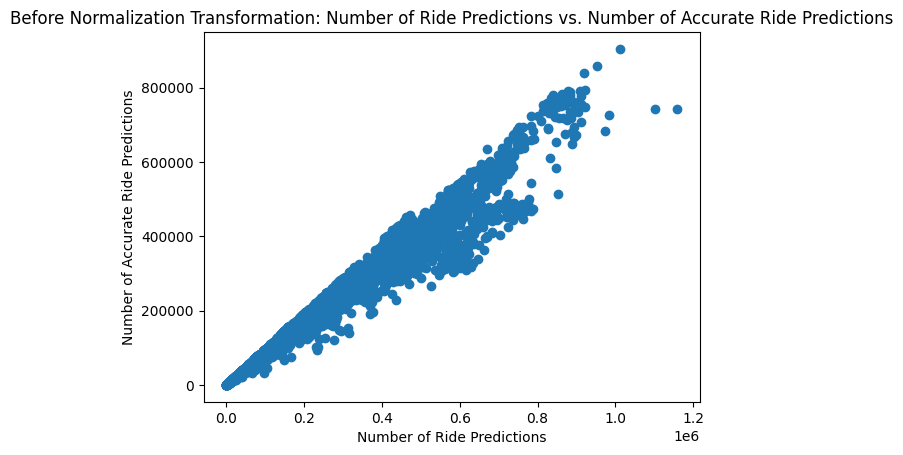

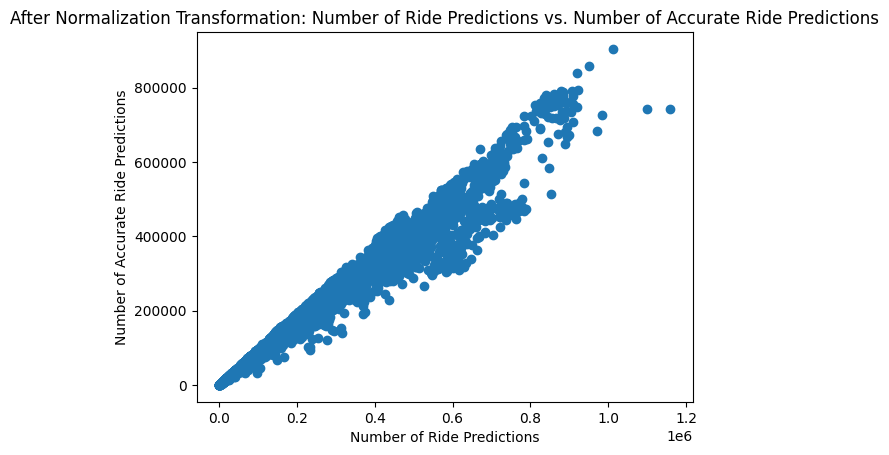

In [84]:
#scatter plot of original data of the "num_predictions" and "num_accurate_predictions" columns before normalization transformation
plt.scatter(ride_accuracy_drop_df["num_predictions"], ride_accuracy_drop_df["num_accurate_predictions"])
plt.title("Before Normalization Transformation: Number of Ride Predictions vs. Number of Accurate Ride Predictions")
plt.xlabel("Number of Ride Predictions")
plt.ylabel("Number of Accurate Ride Predictions")
plt.show()

#scatter plot of original data of the "num_predictions" and "num_accurate_predictions" columns after normalization transformation
#scatter plot shows normalization of dataset is not necessary
plt.scatter(normalized_ride_accuracy[:,0], normalized_ride_accuracy[:,1])
plt.title("After Normalization Transformation: Number of Ride Predictions vs. Number of Accurate Ride Predictions")
plt.xlabel("Number of Ride Predictions")
plt.ylabel("Number of Accurate Ride Predictions")
plt.show()

## Statistical Insights:

In [85]:
#Logistic regression model
#determine relationship between the number of predictions and accurate predictions with binary values of the dates
#import the statsmodel libary
import statsmodels.api as sm
#fit logistic regression model onto the Pre and Post 2021 Binary and num_accurate_predictions column of dataset
log_accuracy_model = sm.Logit(ride_accuracy_drop_df["Pre and Post 2021 Binary"], sm.add_constant(ride_accuracy_drop_df["num_accurate_predictions"])).fit()
#print logistic model summary
print(log_accuracy_model.summary())

Optimization terminated successfully.
         Current function value: 0.631700
         Iterations 5
                              Logit Regression Results                              
Dep. Variable:     Pre and Post 2021 Binary   No. Observations:                 7184
Model:                                Logit   Df Residuals:                     7182
Method:                                 MLE   Df Model:                            1
Date:                      Thu, 12 Dec 2024   Pseudo R-squ.:                0.003487
Time:                              23:06:09   Log-Likelihood:                -4538.1
converged:                             True   LL-Null:                       -4554.0
Covariance Type:                  nonrobust   LLR p-value:                 1.744e-08
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.8

In [86]:
#create a new subset of dataset, drop the Pre and Post 2021 Binary because that column will be used as the predictor to be fit in the logistic regression model
rel_subset2 = rel_subset.drop("Pre and Post 2021 Binary", axis=1)
print(rel_subset2.columns) #print columns of new subset data as checkpoint

Index(['num_predictions', 'num_accurate_predictions',
       'Low Range Bin Time (min)', 'High Range Bin Time (min)'],
      dtype='object')


In [87]:
#fit logistic regression model onto the Pre and Post 2021 Binary and num_accurate_predictions column of dataset
log_accuracy_model2 = sm.Logit(ride_accuracy_drop_df["Pre and Post 2021 Binary"], sm.add_constant(rel_subset2)).fit()
#print logistic model summary
print(log_accuracy_model2.summary())

Optimization terminated successfully.
         Current function value: 0.627313
         Iterations 5
                              Logit Regression Results                              
Dep. Variable:     Pre and Post 2021 Binary   No. Observations:                 7184
Model:                                Logit   Df Residuals:                     7179
Method:                                 MLE   Df Model:                            4
Date:                      Thu, 12 Dec 2024   Pseudo R-squ.:                 0.01041
Time:                              23:06:14   Log-Likelihood:                -4506.6
converged:                             True   LL-Null:                       -4554.0
Covariance Type:                  nonrobust   LLR p-value:                 1.261e-19
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         

In [88]:
#two-sample t-test
#import the scipy.stats library
import scipy.stats as stats

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "num_accurate_predictions" features
t_stat, p_value = stats.ttest_ind(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["num_accurate_predictions"])
print("T-statistic: ", t_stat) #print t-statistic
print("p-value: ", p_value) #print p-value

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "num_predictions" features
t_stat2, p_value2 = stats.ttest_ind(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["num_predictions"])
print("T-statistic: ", t_stat2) #print t-statistic
print("p-value: ", p_value2) #print p-value

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "Low Range Bin Time (min)" features
t_stat3, p_value3 = stats.ttest_ind(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["Low Range Bin Time (min)"])
print("T-statistic: ", t_stat3) #print t-statistic
print("p-value: ", p_value3) #print p-value

#perform two-sample t-test on the "Pre and Post 2021 Binary" and "High Range Bin Time (min)" features
t_stat4, p_value4 = stats.ttest_ind(ride_accuracy_drop_df["Pre and Post 2021 Binary"], ride_accuracy_drop_df["High Range Bin Time (min)"])
print("T-statistic: ", t_stat4) #print t-statistic
print("p-value: ", p_value4) #print p-value


T-statistic:  -90.69515095798823
p-value:  0.0
T-statistic:  -87.41768526850058
p-value:  0.0
T-statistic:  -86.98884263601893
p-value:  0.0
T-statistic:  -97.6541427631758
p-value:  0.0


## Data Visualization and Storytelling:

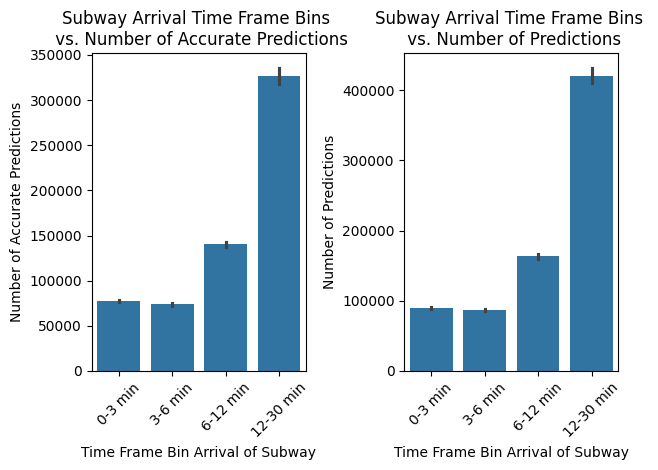

In [89]:
#create bar plot to show number of accurate prediction of subway rides and their arrival timeframe bins
plt.subplot(1,2,1) #create first plot. First row, 2 columns, 1st subplot
sns.barplot(data = ride_accuracy_drop_df, x = "bin", y = "num_accurate_predictions")
plt.title("Subway Arrival Time Frame Bins \n vs. Number of Accurate Predictions")
plt.ylabel("Number of Accurate Predictions")
plt.xlabel("Time Frame Bin Arrival of Subway")
plt.xticks(rotation=45)


#create bar plot to show number of prediction of subway rides and their arrival timeframe bins
#create second subplot
plt.subplot(1,2,2)
sns.barplot(data = ride_accuracy_drop_df, x = "bin", y = "num_predictions")
plt.title("Subway Arrival Time Frame Bins \n vs. Number of Predictions")
plt.ylabel("Number of Predictions")
plt.xlabel("Time Frame Bin Arrival of Subway")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

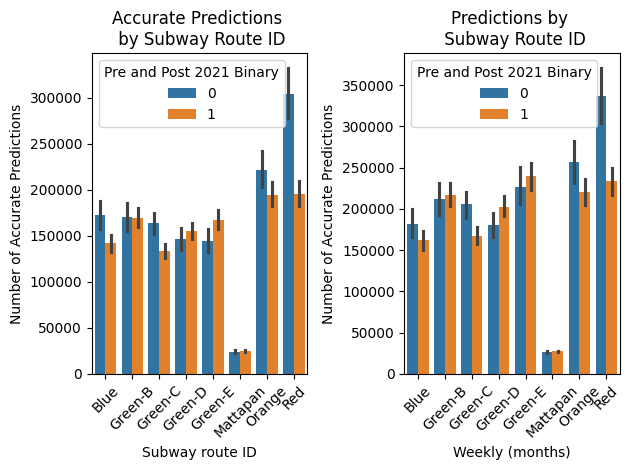

In [95]:
plt.subplot(1,2,1) #create first plot. First row, 2 columns, 1st subplot
sns.barplot(data = ride_accuracy_drop_df, hue = "Pre and Post 2021 Binary", y = "num_accurate_predictions", x = "route_id")
plt.title("Accurate Predictions \n by Subway Route ID")
plt.xlabel("Subway route ID")
plt.ylabel("Number of Accurate Predictions")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.barplot(data = ride_accuracy_drop_df, hue = "Pre and Post 2021 Binary", y = "num_predictions", x = "route_id")
plt.title("Predictions by \n Subway Route ID")
plt.xlabel("Weekly (months)")
plt.ylabel("Number of Accurate Predictions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


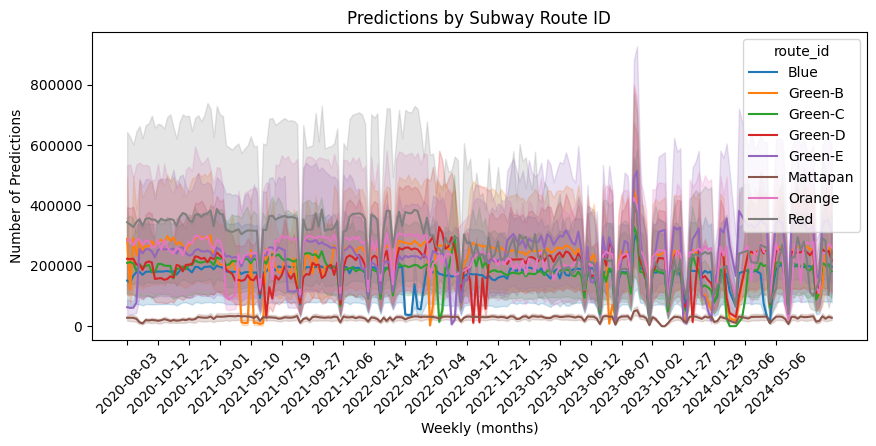

In [109]:
plt.figure(figsize=(10,4))
sns.lineplot(data = ride_accuracy_drop_df, x = "weekly", y = "num_predictions", hue = "route_id")
plt.title("Predictions by Subway Route ID")
plt.xlabel("Weekly (months)")
plt.ylabel("Number of Predictions")
plt.xticks(range(0,220,10))
plt.xticks(rotation=45)
plt.show()

<Figure size 1000x400 with 0 Axes>

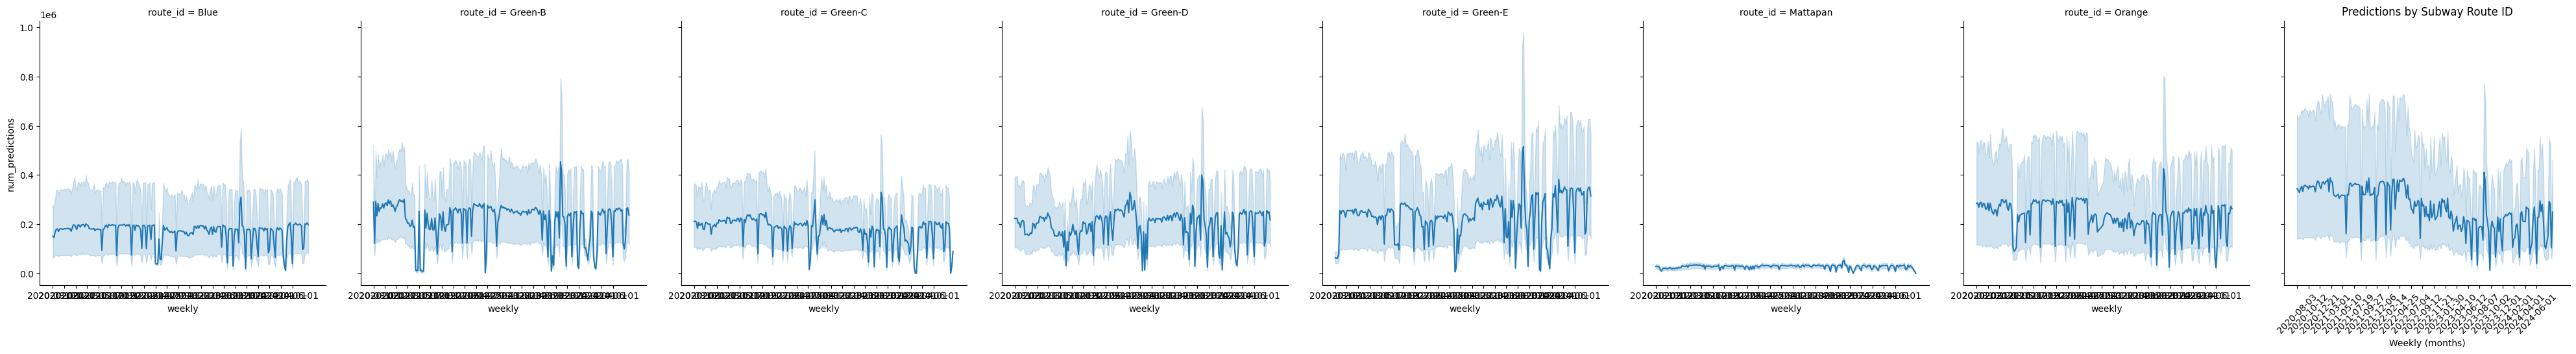

In [112]:
plt.figure(figsize=(10,4))
sns.relplot(data = ride_accuracy_drop_df, x = "weekly", y = "num_predictions", col = "route_id", kind="line")
plt.title("Predictions by Subway Route ID")
plt.xlabel("Weekly (months)")
plt.ylabel("Number of Predictions")
plt.xticks(range(0,220,10))
plt.xticks(rotation=45)
plt.show()

In [24]:
ride_rel = pd.read_csv("../../data/processed-data/Clean_Ride_Reliability.csv")

#convert csv file into a dataframe
ride_rel_df = pd.DataFrame(ride_rel)

print(ride_rel_df.head())


   Unnamed: 0               trip_date  ontime_trip_count  trip_count  \
0           0  2014/07/01 04:00:00+00               5479        5884   
1           1  2014/07/02 04:00:00+00               5297        5612   
2           2  2014/07/03 04:00:00+00               4959        5306   
3           3  2014/07/04 04:00:00+00               1530        1558   
4           4  2014/07/05 04:00:00+00               2420        2580   

   ObjectId        Date         Time  
0         1  2014-07-01  04:00:00+00  
1         2  2014-07-02  04:00:00+00  
2         3  2014-07-03  04:00:00+00  
3         4  2014-07-04  04:00:00+00  
4         5  2014-07-05  04:00:00+00  


In [27]:
data_2019_subset = ride_rel_df[ride_rel_df["Date"] > '2019-01-01']

In [33]:
max_trip = data_2019_subset.nlargest(5000, "ontime_trip_count")

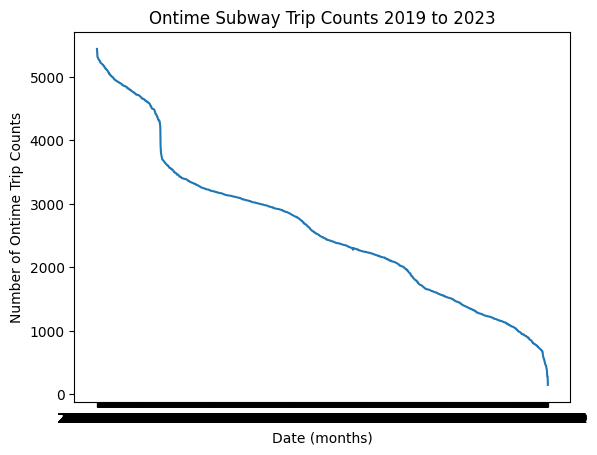

In [34]:
sns.lineplot(data = max_trip, x = "Date", y = "ontime_trip_count")
plt.title("Ontime Subway Trip Counts 2019 to 2023")
plt.xlabel("Date (months)")
plt.ylabel("Number of Ontime Trip Counts")
plt.show()

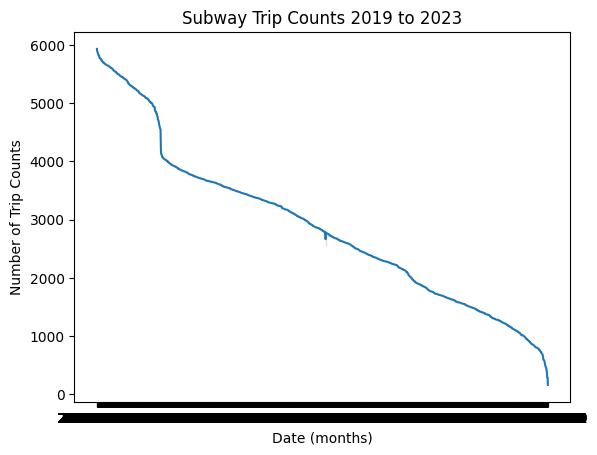

In [38]:
max_trip_count = data_2019_subset.nlargest(5000, "trip_count")

sns.lineplot(data = max_trip_count, x = "Date", y = "trip_count")
plt.title("Subway Trip Counts 2019 to 2023")
plt.xlabel("Date (months)")
plt.ylabel("Number of Trip Counts")
plt.show()

## Conclusions and Next Steps: